# Convert XDF EEG Files to BIDS Format

This notebook converts XDF files containing EEG data from g.USBamp with Unity markers to BIDS format using MNE-BIDS.

## Data Structure
Each XDF file contains 3 streams:
- `g.USBamp-1`: EEG data
- `g.USBamp-1Markers`: Hardware trigger markers
- `UnityMarkerStream`: Unity behavioral markers

## 1. Import Libraries

In [1]:
import pyxdf
import mne
import numpy as np
import pandas as pd
import json
import re
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
from mne_bids import BIDSPath, write_raw_bids
from mne_bids import inspect_dataset
import seaborn as sns
import shutil
import warnings
warnings.filterwarnings('ignore')

# Print version information
print(f"MNE version: {mne.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Plotting backend: {plt.get_backend()}")

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.2)

MNE version: 1.12.1
NumPy version: 2.2.2
Pandas version: 2.2.3
Plotting backend: module://matplotlib_inline.backend_inline


## 2. Define Conversion Function

In [2]:
def convert_xdf_to_bids(xdf_path, bids_root, subject, session, task, run, eeg_reference=None, ground_description=None, powerline_freq=60):
    
    xdf_path = Path(xdf_path)
    bids_root = Path(bids_root)
    
    # Load XDF file
    print(f"\n{'='*60}")
    print(f"Loading: {xdf_path.name}")
    streams, header = pyxdf.load_xdf(xdf_path)
    
    # Identify streams
    eeg_stream = None
    marker_stream = None
    unity_stream = None
    
    print("\nFound streams:")
    for i, stream in enumerate(streams):
        stream_name = stream['info']['name'][0]
        print(f"  Stream {i}: {stream_name}")
        
        if stream_name == 'g.USBamp-1':
            eeg_stream = stream
        elif stream_name == 'g.USBamp-1Markers':
            marker_stream = stream
        elif stream_name == 'UnityMarkerStream':
            unity_stream = stream
    
    if eeg_stream is None:
        raise ValueError("No g.USBamp-1 stream found in XDF file!")
    
    # Extract EEG data
    print("\nExtracting EEG data...")
    eeg_data = eeg_stream['time_series'].T
    sfreq = float(eeg_stream['info']['nominal_srate'][0])
    n_channels, n_samples = eeg_data.shape
    
    # Get EEG time stamps
    eeg_times = eeg_stream['time_stamps']
    eeg_start_time = eeg_times[0] if len(eeg_times) > 0 else 0
    
    print(f"  Channels: {n_channels}, Samples: {n_samples}, Sampling rate: {sfreq} Hz")
    print(f"  EEG start time: {eeg_start_time:.3f}s")
    print(f"  EEG duration: {eeg_times[-1] - eeg_times[0]:.3f}s")
    
    # Get channel names
    ch_names = []
    ch_types = []
    
    if 'desc' in eeg_stream['info'] and len(eeg_stream['info']['desc']) > 0:
        desc = eeg_stream['info']['desc'][0]
        if 'channels' in desc and len(desc['channels']) > 0:
            for ch in desc['channels'][0]['channel']:
                if 'label' in ch:
                    ch_names.append(ch['label'][0])
                else:
                    ch_names.append(f'EEG{len(ch_names)+1:03d}')
                
                ch_label = ch_names[-1].upper()
                if any(x in ch_label for x in ['EOG', 'HEOG', 'VEOG']):
                    ch_types.append('eog')
                elif any(x in ch_label for x in ['ECG', 'EKG']):
                    ch_types.append('ecg')
                elif any(x in ch_label for x in ['EMG']):
                    ch_types.append('emg')
                else:
                    ch_types.append('eeg')
        else:
            ch_names = [f'EEG{i+1:03d}' for i in range(n_channels)]
            ch_types = ['eeg'] * n_channels
    else:
        ch_names = [f'EEG{i+1:03d}' for i in range(n_channels)]
        ch_types = ['eeg'] * n_channels
    
    print(f"  Channel names: {ch_names[:5]}... ({len(ch_names)} total)")
    
    # Create MNE info structure
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(eeg_data, info)
    
    # Handle EEG reference
    if eeg_reference is None:
        reference_description = 'earlobe'
    else:
        raw.set_eeg_reference(eeg_reference, projection=False)
        print(f"  EEG reference set to: {eeg_reference}")
        reference_description = eeg_reference

    # Handle EEG Ground
    if ground_description is None:
        ground_description = 'FPz'
    else:
        print(f"  EEG ground set to: {ground_description}")

    event_onsets = []
    event_durations = []
    event_descriptions = []
    
    # Helper function to align event times to EEG time
    def align_event_time(event_time, eeg_start_time):
        """Convert event time to relative time from EEG start."""
        return float(event_time - eeg_start_time)
    
    # Process hardware markers
    if marker_stream is not None:
        marker_times = marker_stream['time_stamps']
        marker_values = marker_stream['time_series'].flatten().astype(int)
        hardware_count = 0
        
        for time, value in zip(marker_times, marker_values):
            if value != 0:
                # Align time to EEG start
                aligned_time = align_event_time(time, eeg_start_time)
                
                # Check if within data range
                if 0 <= aligned_time <= raw.times[-1]:
                    event_onsets.append(aligned_time)
                    event_durations.append(0.0)
                    event_descriptions.append(f"hardware_{value}")
                    hardware_count += 1
                else:
                    print(f"  Warning: Hardware event at {aligned_time:.3f}s is outside data range (0-{raw.times[-1]:.3f}s)")
        print(f"  Hardware markers found: {hardware_count}")
    
    # Process Unity markers
    if unity_stream is not None:
        unity_times = unity_stream['time_stamps']
        unity_values = unity_stream['time_series']
        unity_count = 0
        
        for i, time in enumerate(unity_times):
            if i < len(unity_values):
                value = unity_values[i]
                if len(value) > 0:
                    if isinstance(value, (list, np.ndarray)):
                        if len(value) > 0:
                            if isinstance(value[0], bytes):
                                marker_name = value[0].decode('utf-8', errors='ignore')
                            else:
                                marker_name = str(value[0])
                        else:
                            continue
                    else:
                        marker_name = str(value)
                    
                    if marker_name and marker_name != '':
                        # Align time to EEG start
                        aligned_time = align_event_time(time, eeg_start_time)
                        
                        # Check if within data range
                        if 0 <= aligned_time <= raw.times[-1]:
                            event_onsets.append(aligned_time)
                            event_durations.append(0.0)
                            event_descriptions.append(f"unity_{marker_name}")
                            unity_count += 1
                        else:
                            print(f"  Warning: Unity event at {aligned_time:.3f}s is outside data range (0-{raw.times[-1]:.3f}s)")
        print(f"  Unity markers found: {unity_count}")
    
    print(f"  Total valid events within data range: {len(event_onsets)}")
    
    # --- Add events to raw object ---
    if len(event_onsets) > 0:
        # Create annotations
        annotations = mne.Annotations(
            onset=event_onsets,
            duration=event_durations,
            description=event_descriptions,
        )
        
        # Try direct assignment
        try:
            raw.annotations = annotations
            print(f"  ✓ Events assigned directly: {len(raw.annotations)} annotations")
        except Exception as e:
            print(f"  Direct assignment failed: {e}")
            try:
                raw.set_annotations(annotations)
                print(f"  ✓ Events added with set_annotations: {len(raw.annotations)} annotations")
            except Exception as e2:
                print(f"  set_annotations also failed: {e2}")
        
        # Verify events were added
        if len(raw.annotations) > 0:
            print(f"  First 5 events in raw object:")
            for i in range(min(5, len(raw.annotations))):
                print(f"    Event {i+1}: onset={raw.annotations.onset[i]:.3f}s, description={raw.annotations.description[i]}")
        else:
            print("WARNING: Events not added to raw object!")
    else:
        print("WARNING: No valid events found within data range!")
        print(f"  Data range: 0 to {raw.times[-1]:.3f}s")
        print(f"  Check that event timestamps are aligned with EEG data")
    
    # --- Write to BIDS ---
    bids_path = BIDSPath(
        subject=subject,
        session=session,
        task=task,
        run=run,
        root=bids_root,
        datatype='eeg'
    )
    
    print(f"\nWriting BIDS files to {bids_root}...")
    
    try:
        write_raw_bids(
            raw, 
            bids_path, 
            format='BrainVision',
            overwrite=True,
            allow_preload=True,
            verbose=True
        )
        print("  BIDS files written successfully!")
    except Exception as e:
        print(f"  Error writing BIDS files: {str(e)}")
        raise
    
    # Update JSON metadata
    json_path = bids_root / f'sub-{subject}' / f'ses-{session}' / 'eeg' / f'sub-{subject}_ses-{session}_task-{task}_run-{run}_eeg.json'
    
    if json_path.exists():
        print("  Adding metadata to JSON sidecar...")
        with open(json_path, 'r') as f:
            metadata = json.load(f)
        
        metadata.update({
            'Manufacturer': 'g.tec',
            'ManufacturerModelName': 'g.USBamp',
            'EEGPlacementScheme': '10-20',
            'EEGReference': reference_description,
            'EEGGround': ground_description,
            'PowerLineFrequency': powerline_freq,
            'RecordingDuration': raw.times[-1],
            'RecordingType': 'continuous',
            'SoftwareVersions': 'g.USBamp Software',
            'SubjectArtefactDescription': 'None',
            'HardwareFilters': {
                'Highpass': {'Frequency': 0, 'Order': 4},
                'Lowpass': {'Frequency': 0, 'Order': 4}
            },
            'SoftwareFilters': {}
        })
        
        with open(json_path, 'w') as f:
            json.dump(metadata, f, indent=2)
        print("  Metadata added successfully!")
    
    print("✓ Conversion complete!")
    
    # Final verification
    print(f"\n{'='*60}")
    print("FINAL VERIFICATION")
    print(f"{'='*60}")
    print(f"Raw object has {len(raw.annotations)} annotations")
    if len(raw.annotations) > 0:
        print(f"Event onsets range: {min(raw.annotations.onset):.3f}s to {max(raw.annotations.onset):.3f}s")
        print(f"Data range: 0 to {raw.times[-1]:.3f}s")
    
    return raw, bids_path

## 3. Run Conversion of one file

In [3]:
# Define paths for a single file
xdf_file = "Data\\PedsData\\EEG\\sub-P034\\ses-S001\\eeg\\sub-P034_ses-S001_task-T1_run-001_eeg.xdf"  # Path to your XDF file
bids_root = 'bids_dataset/'  # Output BIDS directory

# Define BIDS entities
subject = xdf_file.split('\\')[-4].replace('sub-', '')  # Extract subject ID from the path (e.g., 'sub-P047')
session = xdf_file.split('\\')[-1].split('_')[1].replace('ses-', '')  # Extract session ID (e.g., 'S001')
task = xdf_file.split('\\')[-1].split('_')[2].replace('task-', '')  # Extract task ID (e.g., 'T1')
run = xdf_file.split('\\')[-1].split('_')[3].replace('run-', '')  # Extract run ID (e.g., '001')

# Create output directory
Path(bids_root).mkdir(parents=True, exist_ok=True)

raw, bids_path = convert_xdf_to_bids(
    xdf_path=xdf_file,
    bids_root=bids_root,
    subject=subject,
    session=session,
    task=task,
    run=run,
    eeg_reference=None,  # Set to None to handle reference manually
    powerline_freq=60
)

print(f"\n✅ Conversion complete!")
print(f"📁 BIDS files saved to: {bids_path.root / bids_path.directory}")


Loading: sub-P034_ses-S001_task-T1_run-001_eeg.xdf

Found streams:
  Stream 0: UnityMarkerStream
  Stream 1: gUSBamp-1Markers
  Stream 2: g.USBamp-1

Extracting EEG data...
  Channels: 16, Samples: 215936, Sampling rate: 256.0 Hz
  EEG start time: 517548.201s
  EEG duration: 843.528s
  Channel names: ['Fz', 'F4', 'F8', 'C3', 'Cz']... (16 total)
Creating RawArray with float64 data, n_channels=16, n_times=215936
    Range : 0 ... 215935 =      0.000 ...   843.496 secs
Ready.
  Unity markers found: 201
  Total valid events within data range: 201
  Direct assignment failed: property 'annotations' of 'RawArray' object has no setter
  ✓ Events added with set_annotations: 201 annotations
  First 5 events in raw object:
    Event 1: onset=1.049s, description=unity_Trial Started
    Event 2: onset=7.063s, description=unity_ssvep,2,1,10, Contrast1Size1
    Event 3: onset=12.065s, description=unity_getting score
    Event 4: onset=17.198s, description=unity_stimulus ended
    Event 5: onset=22.2

## 4. Validate BIDS Structure

In [4]:
# %% Fixed validation function with better error handling

def validate_bids_dataset(bids_root):
    """
    Validate BIDS dataset structure with comprehensive error handling.
    """
    print("\n" + "="*60)
    print("VALIDATING BIDS DATASET")
    print("="*60)
    
    bids_root = Path(bids_root)
    
    # 1. Check required files
    print("\n1. Checking required files...")
    required_files = [
        'dataset_description.json',
        'participants.tsv',
        'README'
    ]
    
    for file in required_files:
        if (bids_root / file).exists():
            print(f"  ✓ {file} exists")
        else:
            print(f"  ✗ {file} missing")
    
    # 2. Check JSON files for regex compatibility
    print("\n2. Checking JSON sidecar files for regex compatibility...")
    json_files = list(bids_root.glob('**/*.json'))
    
    for json_file in json_files:
        if json_file.name in ['dataset_description.json', 'participants.json']:
            continue
        
        try:
            with open(json_file, 'r') as f:
                metadata = json.load(f)
            
            issues = []
            
            # Check for problematic fields that could affect regex matching
            problematic_fields = ['EEGReference', 'TaskName', 'SubjectArtefactDescription']
            
            for field in problematic_fields:
                if field in metadata:
                    value = str(metadata[field])
                    # Check for characters that might break regex
                    if re.search(r'[\[\]\(\)\{\}\.\+\*\?\\\^\$\|]', value):
                        issues.append(f"{field} contains regex special characters: '{value}'")
            
            # Check HardwareFilters
            if 'HardwareFilters' in metadata:
                if isinstance(metadata['HardwareFilters'], str):
                    issues.append("HardwareFilters is a string, should be a dict")
                elif isinstance(metadata['HardwareFilters'], dict):
                    for k, v in metadata['HardwareFilters'].items():
                        if isinstance(v, str):
                            issues.append(f"HardwareFilters.{k} is a string")
            
            # Check SoftwareFilters
            if 'SoftwareFilters' in metadata:
                if isinstance(metadata['SoftwareFilters'], str):
                    issues.append("SoftwareFilters is a string, should be a dict")
            
            if issues:
                print(f"  ⚠ {json_file.relative_to(bids_root)} has issues:")
                for issue in issues:
                    print(f"     - {issue}")
            else:
                print(f"  ✓ {json_file.relative_to(bids_root)} is valid")
                
        except Exception as e:
            print(f"  ✗ Error checking {json_file.relative_to(bids_root)}: {e}")
    
    # 3. List all subjects
    print("\n3. Found subjects:")
    subjects = [d.name.replace('sub-', '') for d in bids_root.glob('sub-*') if d.is_dir()]
    for subject in subjects:
        print(f"  - {subject}")
    
    # 4. Check EEG files
    print("\n4. Found EEG files:")
    eeg_files = list(bids_root.glob('sub-*/ses-*/eeg/*.vhdr'))
    for eeg_file in eeg_files[:5]:
        print(f"  - {eeg_file.relative_to(bids_root)}")
    if len(eeg_files) > 5:
        print(f"  ... and {len(eeg_files) - 5} more")
    
    if len(eeg_files) == 0:
        print("  ⚠ No EEG files found!")
    
    return subjects

# Run validation
subjects = validate_bids_dataset(bids_root)


VALIDATING BIDS DATASET

1. Checking required files...
  ✓ dataset_description.json exists
  ✓ participants.tsv exists
  ✓ README exists

2. Checking JSON sidecar files for regex compatibility...
  ✓ sub-P047\ses-S001\eeg\sub-P047_ses-S001_task-T1_run-001_eeg.json is valid
  ✓ sub-P047\ses-S001\eeg\sub-P047_ses-S001_task-T1_run-001_events.json is valid
  ✓ sub-P034\ses-S001\eeg\sub-P034_ses-S001_task-T1_run-001_eeg.json is valid
  ✓ sub-P034\ses-S001\eeg\sub-P034_ses-S001_task-T1_run-001_events.json is valid

3. Found subjects:
  - P034
  - P047

4. Found EEG files:
  - sub-P034\ses-S001\eeg\sub-P034_ses-S001_task-T1_run-001_eeg.vhdr
  - sub-P047\ses-S001\eeg\sub-P047_ses-S001_task-T1_run-001_eeg.vhdr


## 5. Basic Signal Quality Plots

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().


Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


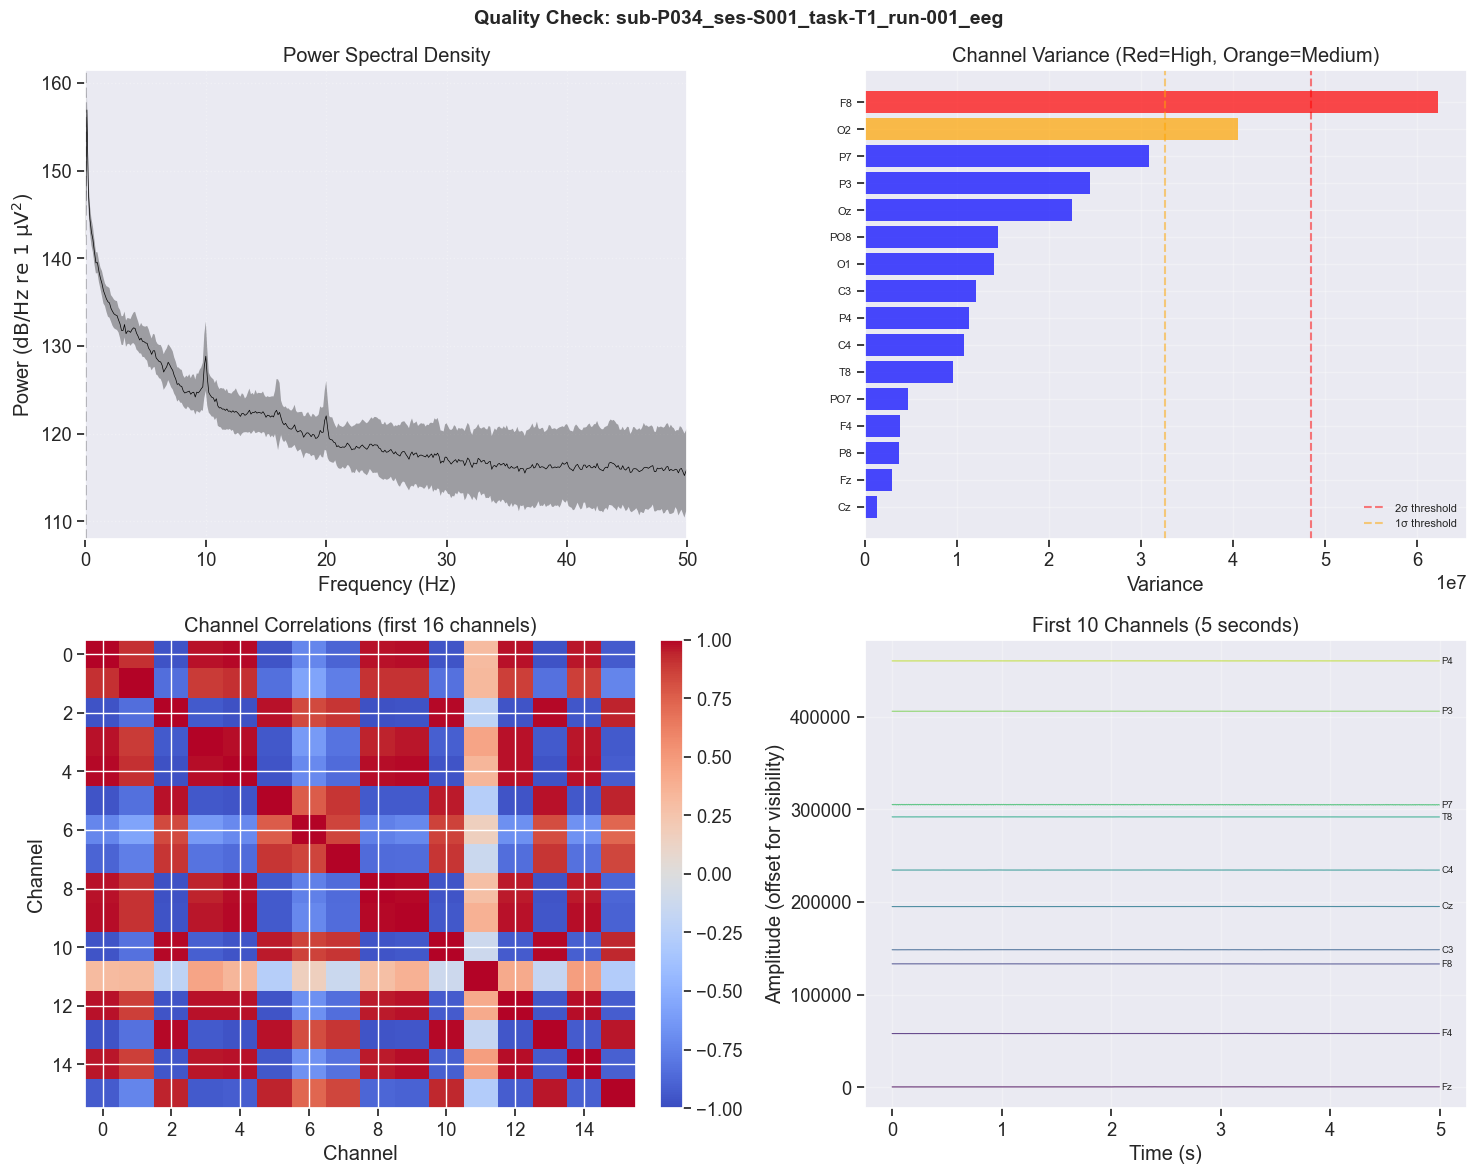

In [5]:
def plot_basic_quality(raw, title="EEG Signal Quality"):
    """
    Create basic quality plots for EEG data.
    """
    fig = plt.figure(figsize=(15, 12))
    
    # 1. Power Spectral Density
    ax1 = plt.subplot(2, 2, 1)
    raw.plot_psd(fmax=50, ax=ax1, show=False, average=True)
    ax1.set_title('Power Spectral Density')
    ax1.grid(True, alpha=0.3)
    
    # 2. Channel variance
    ax2 = plt.subplot(2, 2, 2)
    data, _ = raw[:, :]
    variance = np.var(data, axis=1)
    ch_names = raw.ch_names
    
    # Sort by variance
    sorted_idx = np.argsort(variance)
    sorted_names = [ch_names[i] for i in sorted_idx]
    sorted_var = variance[sorted_idx]
    
    colors = ['red' if v > np.mean(variance) + 2*np.std(variance) else 
              'orange' if v > np.mean(variance) + np.std(variance) else 
              'blue' for v in sorted_var]
    
    bars = ax2.barh(range(len(sorted_names)), sorted_var, color=colors, alpha=0.7)
    ax2.set_yticks(range(len(sorted_names)))
    ax2.set_yticklabels(sorted_names, fontsize=8)
    ax2.set_xlabel('Variance')
    ax2.set_title('Channel Variance (Red=High, Orange=Medium)')
    ax2.axvline(np.mean(variance) + 2*np.std(variance), color='red', linestyle='--', alpha=0.5, label='2σ threshold')
    ax2.axvline(np.mean(variance) + np.std(variance), color='orange', linestyle='--', alpha=0.5, label='1σ threshold')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # 3. Channel correlations
    ax3 = plt.subplot(2, 2, 3)
    data_subset = raw.get_data(picks=range(min(20, len(raw.ch_names))), 
                                start=0, stop=min(10000, raw.n_times))
    corr = np.corrcoef(data_subset)
    im = ax3.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    ax3.set_title(f'Channel Correlations (first {min(20, len(raw.ch_names))} channels)')
    ax3.set_xlabel('Channel')
    ax3.set_ylabel('Channel')
    plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
    
    # 4. Channel time series (first 10 channels, 5 seconds)
    ax4 = plt.subplot(2, 2, 4)
    duration = 5  # seconds
    n_samples = int(duration * raw.info['sfreq'])
    n_channels = min(10, len(raw.ch_names))
    
    data_sample, times = raw[:, :n_samples]
    
    # Plot with offsets for visibility
    for i in range(n_channels):
        offset = i * np.std(data_sample) * 3
        ax4.plot(times, data_sample[i, :] + offset, 
                 color=plt.cm.viridis(i/n_channels), 
                 linewidth=0.8, alpha=0.8)
        ax4.text(times[-1] + 0.02, data_sample[i, -1] + offset, 
                 raw.ch_names[i], fontsize=7, va='center')
    
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Amplitude (offset for visibility)')
    ax4.set_title(f'First {n_channels} Channels (5 seconds)')
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run quality plots
plot_basic_quality(raw, f"Quality Check: {Path(bids_path.fpath).stem}")

## 6. Event Analysis


EVENT ANALYSIS
Number of events: 201
Unique event types: 35
Event types: ['unity_Trial Started' 'unity_baseline ended' 'unity_getting score'
 'unity_off' 'unity_ssvep,2,1,10, Contrast1Size1'
 'unity_ssvep,2,1,10, Contrast1Size2' 'unity_ssvep,2,1,10, Contrast1Size3'
 'unity_ssvep,2,1,10, Contrast2Size1' 'unity_ssvep,2,1,10, Contrast2Size2'
 'unity_ssvep,2,1,10, Contrast2Size3']...


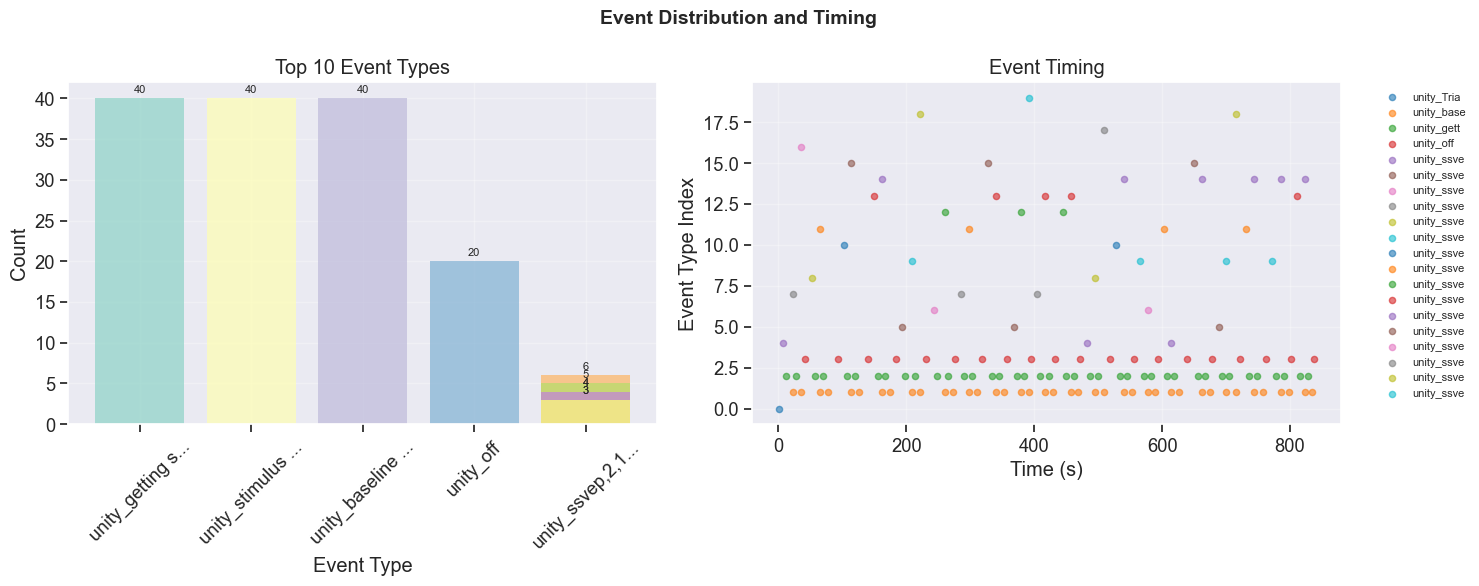


Event Statistics:
  unity_getting score: 40 events, first at 12.07s, last at 828.74s
  unity_stimulus ended: 40 events, first at 17.20s, last at 829.98s
  unity_baseline ended: 40 events, first at 22.21s, last at 834.99s
  unity_off: 20 events, first at 41.94s, last at 838.03s
  unity_ssvep,2,1,10, Contrast4Size2: 6 events, first at 161.45s, last at 823.73s
  unity_ssvep,2,1,10, Contrast4Size1: 5 events, first at 150.07s, last at 810.96s
  unity_ssvep,2,1,10, Contrast3Size2: 4 events, first at 65.34s, last at 731.13s
  unity_ssvep,2,1,10, Contrast2Size3: 4 events, first at 209.22s, last at 772.19s
  unity_ssvep,2,1,10, Contrast1Size1: 3 events, first at 7.06s, last at 614.20s
  unity_ssvep,2,1,10, Contrast2Size1: 3 events, first at 22.21s, last at 404.56s


In [6]:
def analyze_events(raw):
    """
    Analyze and visualize events in the data.
    """
    print("\n" + "="*60)
    print("EVENT ANALYSIS")
    print("="*60)
    
    if len(raw.annotations) == 0:
        print("No events found in the data!")
        return
    
    annotations = raw.annotations
    print(f"Number of events: {len(annotations)}")
    
    # Get event descriptions
    descriptions = np.unique(annotations.description)
    print(f"Unique event types: {len(descriptions)}")
    print(f"Event types: {descriptions[:10]}...")
    
    # Count events by type
    from collections import Counter
    event_counts = Counter(annotations.description)
    
    # Create event visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Event distribution
    ax1 = axes[0]
    top_events = event_counts.most_common(10)
    events, counts = zip(*top_events)
    
    # Truncate long event names
    events_short = [e[:15] + '...' if len(e) > 15 else e for e in events]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(events)))
    bars = ax1.bar(events_short, counts, color=colors, alpha=0.7)
    ax1.set_xlabel('Event Type')
    ax1.set_ylabel('Count')
    ax1.set_title('Top 10 Event Types')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, count) in enumerate(zip(bars, counts)):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(count), ha='center', va='bottom', fontsize=8)
    
    # Plot 2: Event timing
    ax2 = axes[1]
    times = annotations.onset
    
    # Create event timing plot
    for i, desc in enumerate(descriptions[:20]):  # Limit to first 20 types
        mask = np.array(annotations.description) == desc
        times_subset = times[mask]
        if len(times_subset) > 0:
            ax2.scatter(times_subset, [i]*len(times_subset), 
                       s=20, alpha=0.6, label=desc[:10])
    
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Event Type Index')
    ax2.set_title('Event Timing')
    ax2.grid(True, alpha=0.3)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.suptitle('Event Distribution and Timing', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print event statistics
    print("\nEvent Statistics:")
    for desc, count in event_counts.most_common(10):
        times = [t for t, d in zip(annotations.onset, annotations.description) if d == desc]
        print(f"  {desc}: {count} events, first at {times[0]:.2f}s, last at {times[-1]:.2f}s")

# Analyze events
analyze_events(raw)

## 8. Load BIDS Data

In [7]:
# %% Function to load BIDS data
def load_bids_data(bids_root, subject, session, task, run):
    """
    Load BIDS data and return raw object with metadata.
    
    Parameters:
    -----------
    bids_root : str or Path
        Root directory of the BIDS dataset
    subject : str
        Subject ID (e.g., 'P047')
    session : str
        Session ID (e.g., 'S001')
    task : str
        Task name (e.g., 'T1')
    run : str or int
        Run number (e.g., '001')
    
    Returns:
    --------
    raw : mne.io.Raw
        MNE Raw object containing the data
    bids_path : mne_bids.BIDSPath
        BIDS path object
    """
    
    from mne_bids import BIDSPath, read_raw_bids
    import json
    from pathlib import Path
    
    bids_path = BIDSPath(
        subject=subject,
        session=session,
        task=task,
        run=run,
        root=bids_root,
        datatype='eeg'
    )
    
    print(f"\n{'='*60}")
    print(f"LOADING BIDS DATA")
    print(f"{'='*60}")
    print(f"  Subject: {subject}")
    print(f"  Session: {session}")
    print(f"  Task: {task}")
    print(f"  Run: {run}")
    
    # Check if file exists
    vhdr_path = bids_path.fpath.with_suffix('.vhdr')
    if not vhdr_path.exists():
        raise FileNotFoundError(f"File not found: {vhdr_path}")
    
    print(f"  File: {vhdr_path}")
    
    # Load the data
    raw = read_raw_bids(bids_path, verbose=False)
    
    print(f"\n{'='*60}")
    print("DATA SUMMARY")
    print(f"{'='*60}")
    print(f"  Channels: {len(raw.ch_names)}")
    print(f"  Sampling rate: {raw.info['sfreq']:.1f} Hz")
    print(f"  Duration: {raw.times[-1]:.2f} seconds")
    print(f"  Events: {len(raw.annotations)}")
    if len(raw.annotations) > 0:
        print(f"  Event types: {np.unique(raw.annotations.description)[:5]}...")
    
    # Load metadata from JSON
    json_path = bids_path.fpath.with_suffix('.json')
    if json_path.exists():
        with open(json_path, 'r') as f:
            metadata = json.load(f)
        print(f"\n  Metadata from JSON:")
        for key, value in list(metadata.items())[:5]:  # Show first 5 items
            if not isinstance(value, dict):  # Skip nested dicts
                print(f"    {key}: {value}")
    
    return raw, bids_path

## 9. One-Cell Full Validation and Plotting

FULL VALIDATION AND PLOTTING

VALIDATING BIDS DATASET

1. Checking required files...
  ✓ dataset_description.json exists
  ✓ participants.tsv exists
  ✓ README exists

2. Checking JSON sidecar files for regex compatibility...
  ✓ sub-P047\ses-S001\eeg\sub-P047_ses-S001_task-T1_run-001_eeg.json is valid
  ✓ sub-P047\ses-S001\eeg\sub-P047_ses-S001_task-T1_run-001_events.json is valid
  ✓ sub-P034\ses-S001\eeg\sub-P034_ses-S001_task-T1_run-001_eeg.json is valid
  ✓ sub-P034\ses-S001\eeg\sub-P034_ses-S001_task-T1_run-001_events.json is valid

3. Found subjects:
  - P034
  - P047

4. Found EEG files:
  - sub-P034\ses-S001\eeg\sub-P034_ses-S001_task-T1_run-001_eeg.vhdr
  - sub-P047\ses-S001\eeg\sub-P047_ses-S001_task-T1_run-001_eeg.vhdr

LOADING BIDS DATA
  Subject: P034
  Session: S001
  Task: T1
  Run: 001
  File: bids_dataset\sub-P034\ses-S001\eeg\sub-P034_ses-S001_task-T1_run-001_eeg.vhdr

DATA SUMMARY
  Channels: 16
  Sampling rate: 256.0 Hz
  Duration: 843.50 seconds
  Events: 201
  Ev

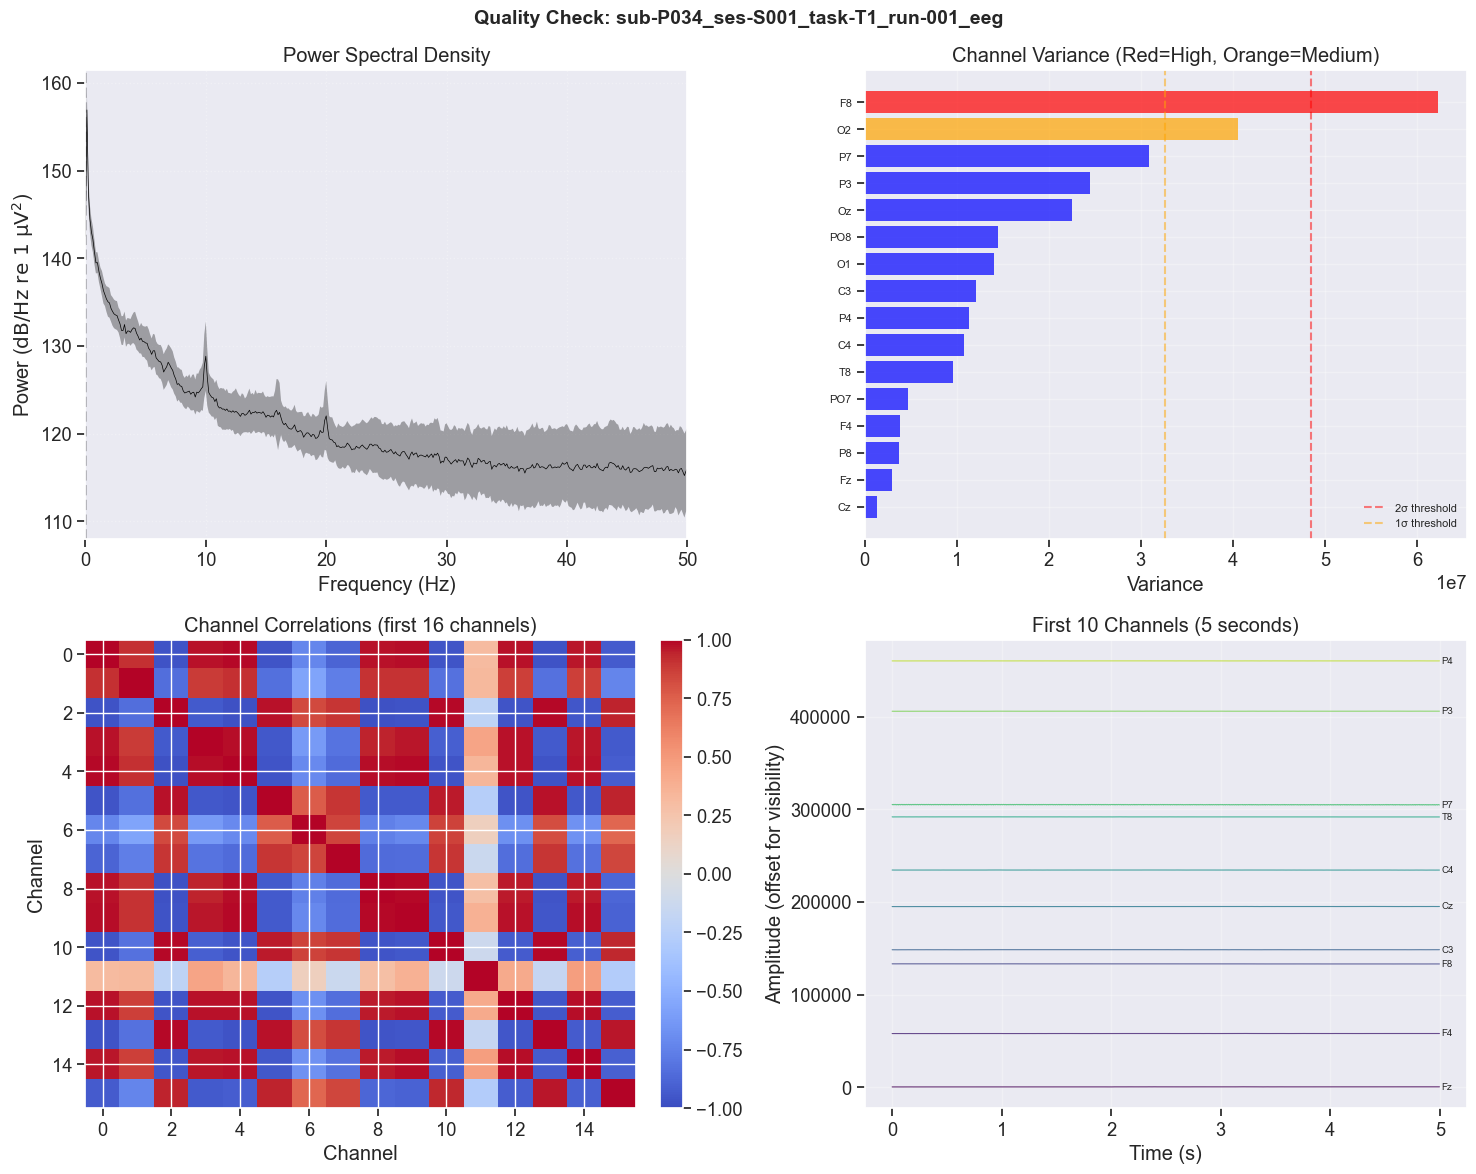


EVENT ANALYSIS
Number of events: 201
Unique event types: 35
Event types: ['unity_Trial Started' 'unity_baseline ended' 'unity_getting score'
 'unity_off' 'unity_ssvep,2,1,10, Contrast1Size1'
 'unity_ssvep,2,1,10, Contrast1Size2' 'unity_ssvep,2,1,10, Contrast1Size3'
 'unity_ssvep,2,1,10, Contrast2Size1' 'unity_ssvep,2,1,10, Contrast2Size2'
 'unity_ssvep,2,1,10, Contrast2Size3']...


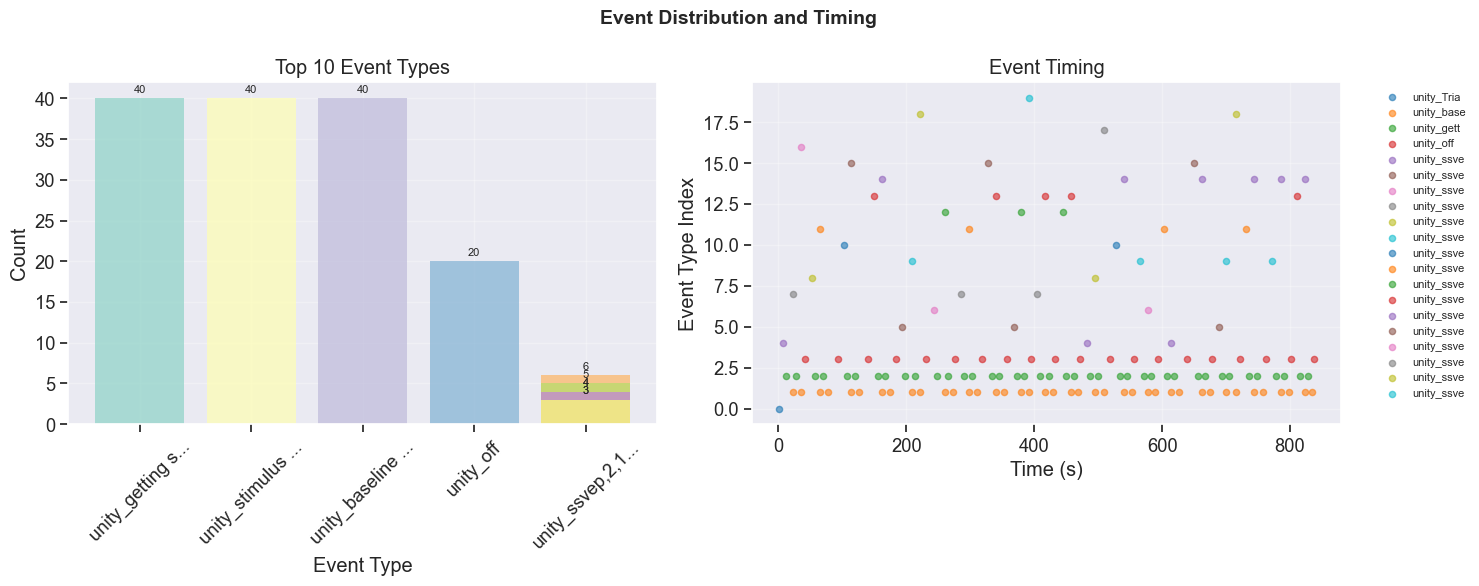


Event Statistics:
  unity_getting score: 40 events, first at 12.07s, last at 828.73s
  unity_stimulus ended: 40 events, first at 17.20s, last at 829.98s
  unity_baseline ended: 40 events, first at 22.21s, last at 834.99s
  unity_off: 20 events, first at 41.94s, last at 838.03s
  unity_ssvep,2,1,10, Contrast4Size2: 6 events, first at 161.45s, last at 823.73s
  unity_ssvep,2,1,10, Contrast4Size1: 5 events, first at 150.07s, last at 810.96s
  unity_ssvep,2,1,10, Contrast3Size2: 4 events, first at 65.34s, last at 731.13s
  unity_ssvep,2,1,10, Contrast2Size3: 4 events, first at 209.22s, last at 772.19s
  unity_ssvep,2,1,10, Contrast1Size1: 3 events, first at 7.06s, last at 614.20s
  unity_ssvep,2,1,10, Contrast2Size1: 3 events, first at 22.21s, last at 404.56s

DATA INTEGRITY
  Missing values: 0
  Infinite values: 0
  Dynamic range: -5.40e+04 to 3.61e+04 V
  Mean: -6.39e+01 V
  Std: 1.62e+04 V

✅ VALIDATION AND PLOTTING COMPLETE!


In [9]:
# Run everything in one cell for quick validation
print("="*60)
print("FULL VALIDATION AND PLOTTING")
print("="*60)

# 1. Validate structure
subjects = validate_bids_dataset(bids_root)

# 2. Load data
raw, bids_path = load_bids_data(bids_root, subject, session, task, run)

# 3. Quality plots
plot_basic_quality(raw, f"Quality Check: {Path(bids_path.fpath).stem}")

# 4. Event analysis
analyze_events(raw)

# 5. Data integrity
data, _ = raw[:, :]
print("\n" + "="*60)
print("DATA INTEGRITY")
print("="*60)
print(f"  Missing values: {np.isnan(data).sum()}")
print(f"  Infinite values: {np.isinf(data).sum()}")
print(f"  Dynamic range: {np.min(data):.2e} to {np.max(data):.2e} V")
print(f"  Mean: {np.mean(data):.2e} V")
print(f"  Std: {np.std(data):.2e} V")

print("\n" + "="*60)
print("✅ VALIDATION AND PLOTTING COMPLETE!")
print("="*60)